# VQ capacity / quantized speaker supervision and raw clusterability
All settings are prespecified: (5,10) and (64,64) codebooks; speaker CE on straight-through z_s; lambda 0, 0.1, 1, 10; five paired seeds. Fixed final epoch 80 replaces reconstruction-based checkpoint/weight selection. Phoneme labels are used only in post-training evaluation and frozen train-fitted mappings.

Raw k-means and full-covariance GMM have five clusters, with pooled, individual-speaker, and speaker-normalized fits. Normalization uses only that familiar speaker's training tokens; no held-out-speaker normalization is estimated. Pooled models also evaluate unseen speakers. The existing 13-speaker selection, split and preprocessing are verified exactly.

In [1]:
from pathlib import Path
import sys, json, runpy, subprocess
from dataclasses import asdict
import pandas as pd
from IPython.display import display, Markdown, Image
ROOT = Path.cwd() if (Path.cwd()/'src').exists() else Path.cwd().parent
sys.path.insert(0,str(ROOT))
CONFIG_PATH = ROOT/'src/configs/vq_sensitivity.py'
config = runpy.run_path(str(CONFIG_PATH))['CONFIG']
print('Anaconda interpreter:',sys.executable)
display(asdict(config))
# Set None for a new experiment; completed runs load without retraining.
RESUME_RUN = ROOT/'outputs/vq_sensitivity/20260929_011130_ec2936'

Anaconda interpreter: C:\Users\46021\.conda\envs\lffl\python.exe


{'data': {'csv_path': 'metadata_vowels_acoustics.csv',
  'features': ('f0_median_hz', 'f1_hz', 'f2_hz', 'f3_hz', 'duration_s'),
  'n_speakers': 10,
  'speaker_ids': None,
  'seed': 2026,
  'split': (0.8, 0.1, 0.1),
  'log_features': False},
 'training_speakers': ('jvs003',
  'jvs009',
  'jvs018',
  'jvs036',
  'jvs037',
  'jvs038',
  'jvs046',
  'jvs061',
  'jvs065',
  'jvs078'),
 'heldout_count': 3,
 'hidden_dims': (128, 128),
 'embedding_dim': 8,
 'commitment': 0.25,
 'lambdas': (0.0, 0.1, 1.0, 10.0),
 'selection_seeds': (42, 43, 44),
 'seeds': (42, 43, 44, 45, 46),
 'baseline_seeds': (42, 43, 44),
 'selection_epochs': 40,
 'epochs': 80,
 'pretrain_epochs': 10,
 'batch_size': 512,
 'learning_rate': 0.001,
 'workers': 2,
 'threads': 1,
 'output_dir': 'outputs/vq_sensitivity',
 'codebook_pairs': ((5, 10), (64, 64)),
 'kmeans_n_init': 10,
 'gmm_n_init': 5,
 'gmm_max_iter': 300,
 'gmm_reg_covar': 1e-05,
 'reference_run': 'outputs/dual_vq/20260928_190154_268b85'}

In [2]:
command = [sys.executable,str(ROOT/'src/train_sensitivity.py'),'--config',str(CONFIG_PATH)]
if RESUME_RUN is not None:
    command += ['--resume',str(RESUME_RUN)]
p = subprocess.Popen(command,cwd=ROOT,stdout=subprocess.PIPE,stderr=subprocess.STDOUT,text=True)
run_dir = RESUME_RUN
for line in p.stdout:
    print(line,end='')
    if line.startswith('RUN DIRECTORY: '):
        run_dir = Path(line.strip().split('RUN DIRECTORY: ',1)[1])
assert p.wait() == 0
assert (run_dir/'complete.json').exists()
display(json.loads((run_dir/'complete.json').read_text()))

COMPLETE: E:\SynologyDrive\Documents\research\variation_perceptual_magnet\codes\outputs\vq_sensitivity\20260929_011130_ec2936


{'vq_runs': 40, 'raw_model_fits': 120, 'matched_initialization_verified': True}

## Interpretation of metrics
With 64 codes, multiple codes may represent one vowel: report training-fitted majority mappings (many-to-one), NMI, ARI and AMI. Unused training codes fall back to the training-majority class. Do not equate these accuracies with old one-to-one Hungarian scores. Five-code controls retain both measures.

Individual-speaker clustering uses separate train-fitted mappings. Its micro/macro NMI and ARI are weighted/unweighted averages of within-speaker metrics, not clustering of pooled arbitrary local code IDs. Speaker-normalized and individual models have no unseen-speaker test under this strict no-adaptation protocol.

In [3]:
data_info = json.loads((run_dir/'data.json').read_text())
display(pd.DataFrame(data_info['speaker_counts']).fillna(0).astype(int))
raw = pd.read_csv(run_dir/'raw_seed_metrics.csv')
display(raw[raw.split.ne('val')].groupby(['method','view','split'])[['phoneme_hungarian_accuracy','phoneme_accuracy','phi_phi_nmi','phi_phi_ari']].agg(['mean','std']))
vq = pd.read_csv(run_dir/'vq_metrics.csv')
display(vq[vq.split.ne('val')].groupby(['k_phi','k_s','lambda_s','split'])[['phoneme_accuracy','mse','phi_phi_nmi','phi_s_nmi','s_s_nmi']].agg(['mean','std']))
display(pd.read_csv(run_dir/'paired_dose_effects.csv'))
display(pd.read_csv(run_dir/'paired_capacity_effects.csv'))

,train,val,test_seen,test_unseen
jvs003,3667,458,459,0
jvs009,3710,464,464,0
jvs018,3782,473,473,0
jvs036,3696,462,462,0
jvs037,3622,453,453,0
jvs038,3642,455,456,0
jvs046,3673,459,460,0
jvs061,3702,463,463,0
jvs065,3704,463,463,0
jvs078,3665,458,459,0


phoneme_hungarian_accuracy            \
                                                            mean       std   
method view               split                                              
gmm    individual_macro   test_seen                     0.484724  0.010858   
       individual_micro   test_seen                     0.484562  0.010793   
       pooled             test_seen                     0.351951  0.000097   
                          test_unseen                   0.341561  0.000122   
       speaker_normalized test_seen                     0.410321  0.000394   
kmeans individual_macro   test_seen                     0.494968  0.006959   
       individual_micro   test_seen                     0.495056  0.006927   
       pooled             test_seen                     0.354163  0.000499   
                          test_unseen                   0.335233  0.000358   
       speaker_normalized test_seen                     0.434909  0.000322   

                                      phoneme_accuracy           phi_phi_nmi  \
                                                  mean       std        mean   
method view               split                                                
gmm    individual_macro   test_seen           0.522513  0.005201    0.360474   
       individual_micro   test_seen           0.522550  0.005126    0.360427   
       pooled             test_seen           0.385863  0.000119    0.154680   
                          test_unseen         0.341634  0.000040    0.142564   
       speaker_normalized test_seen           0.466522  0.000565    0.268925   
kmeans individual_macro   test_seen           0.545105  0.008429    0.349494   
       individual_micro   test_seen           0.545273  0.008388    0.349479   
       pooled             test_seen           0.411188  0.000450    0.133252   
                          test_unseen         0.383560  0.000191    0.125184   
       speaker_normalized test_seen           0.467173  0.000363    0.184301   

                                                phi_phi_ari            
                                            std        mean       std  
method view               split                                        
gmm    individual_macro   test_seen    0.002941    0.276567  0.004219  
       individual_micro   test_seen    0.002912    0.276617  0.004164  
       pooled             test_seen    0.000202    0.089692  0.000053  
                          test_unseen  0.000010    0.077166  0.000005  
       speaker_normalized test_seen    0.000252    0.228015  0.000197  
kmeans individual_macro   test_seen    0.004081    0.288941  0.005922  
       individual_micro   test_seen    0.004062    0.288968  0.005894  
       pooled             test_seen    0.000725    0.099823  0.000549  
                          test_unseen  0.000627    0.089169  0.000780  
       speaker_normalized test_seen    0.000505    0.144473  0.000374

phoneme_accuracy                 mse            \
                                           mean       std      mean       std   
k_phi k_s lambda_s split                                                        
5     10  0.0      test_seen           0.390633  0.114573  0.205441  0.003463   
                   test_unseen         0.369034  0.109483  0.198150  0.006378   
          0.1      test_seen           0.464180  0.135911  0.209600  0.013814   
                   test_unseen         0.454888  0.108905  0.205386  0.019798   
          1.0      test_seen           0.490069  0.074915  0.287966  0.013232   
                   test_unseen         0.469677  0.088618  0.283728  0.015596   
          10.0     test_seen           0.413747  0.027830  0.397558  0.019199   
                   test_unseen         0.368303  0.032990  0.399506  0.018138   
64    64  0.0      test_seen           0.497528  0.118719  0.043853  0.002118   
                   test_unseen         0.477422  0.120880  0.043792  0.001150   
          0.1      test_seen           0.610191  0.094245  0.050653  0.001076   
                   test_unseen         0.588017  0.097237  0.050623  0.001375   
          1.0      test_seen           0.698222  0.020171  0.077193  0.002450   
                   test_unseen         0.676019  0.022923  0.078773  0.003683   
          10.0     test_seen           0.691804  0.010573  0.087977  0.001183   
                   test_unseen         0.661976  0.017175  0.088726  0.003470   

                               phi_phi_nmi           phi_s_nmi            \
                                      mean       std      mean       std   
k_phi k_s lambda_s split                                                   
5     10  0.0      test_seen      0.134123  0.119262  0.081159  0.041322   
                   test_unseen    0.120064  0.107748  0.073901  0.047554   
          0.1      test_seen      0.203955  0.136991  0.040026  0.008501   
                   test_unseen    0.205440  0.110816  0.038157  0.004640   
          1.0      test_seen      0.245609  0.047032  0.025002  0.009779   
                   test_unseen    0.232563  0.051713  0.037012  0.021953   
          10.0     test_seen      0.156189  0.022691  0.037839  0.011728   
                   test_unseen    0.132081  0.035390  0.020096  0.003633   
64    64  0.0      test_seen      0.163027  0.074962  0.125547  0.020616   
                   test_unseen    0.169537  0.062628  0.120179  0.020469   
          0.1      test_seen      0.227171  0.066078  0.083787  0.007414   
                   test_unseen    0.220788  0.064848  0.071685  0.014273   
          1.0      test_seen      0.283113  0.014144  0.088975  0.012195   
                   test_unseen    0.280806  0.012741  0.099119  0.004299   
          10.0     test_seen      0.282287  0.005781  0.113556  0.006672   
                   test_unseen    0.277066  0.003550  0.120609  0.004572   

                                 s_s_nmi            
                                    mean       std  
k_phi k_s lambda_s split                            
5     10  0.0      test_seen    0.117854  0.034663  
                   test_unseen  0.151868  0.052553  
          0.1      test_seen    0.191326  0.008862  
                   test_unseen  0.215248  0.007004  
          1.0      test_seen    0.308301  0.006128  
                   test_unseen  0.264077  0.008333  
          10.0     test_seen    0.325235  0.003233  
                   test_unseen  0.259847  0.010909  
64    64  0.0      test_seen    0.144268  0.032635  
                   test_unseen  0.122078  0.038237  
          0.1      test_seen    0.251135  0.007810  
                   test_unseen  0.211872  0.006620  
          1.0      test_seen    0.302714  0.005016  
                   test_unseen  0.213599  0.004760  
          10.0     test_seen    0.303509  0.003498  
                   test_unseen  0.215048  0.002975

,k_phi,k_s,seed,split,lambda_s,phoneme_accuracy,phi_phi_nmi,phi_phi_ari,phi_s_nmi,s_s_nmi,s_phi_nmi,mse
0,5,10,42,val,0.1,0.045573,0.036136,0.027576,-0.092396,0.111665,-0.077465,-0.003772
1,5,10,42,val,1.0,0.133898,0.192156,0.137814,-0.124441,0.241631,-0.256392,0.063132
2,5,10,42,val,10.0,0.124349,0.121687,0.083418,-0.113250,0.265241,-0.276352,0.175645
3,5,10,42,test_seen,0.1,0.044232,0.043279,0.030591,-0.095873,0.108925,-0.080529,-0.005544
4,5,10,42,test_seen,1.0,0.131180,0.187151,0.135102,-0.121848,0.241597,-0.242311,0.059446
...,...,...,...,...,...,...,...,...,...,...,...,...
85,64,64,46,test_seen,1.0,0.096921,0.042743,0.010920,-0.048516,0.190812,-0.008877,0.031637
86,64,64,46,test_seen,10.0,0.083044,0.036447,0.008901,-0.006731,0.185112,0.001912,0.043619
87,64,64,46,test_unseen,0.1,-0.045886,-0.033619,-0.002688,-0.071396,0.120494,0.017500,0.007384
88,64,64,46,test_unseen,1.0,0.100687,0.053567,0.014348,-0.033867,0.119518,-0.045640,0.031037


,lambda_s,seed,split,phoneme_accuracy,phi_phi_nmi,phi_phi_ari,phi_s_nmi,s_s_nmi,s_phi_nmi,mse
0,0.0,42,val,0.057943,0.044260,-0.004869,-0.004448,0.077886,-0.020106,-0.167126
1,0.0,42,test_seen,0.068734,0.049364,-0.002781,-0.012207,0.073952,-0.012390,-0.167102
2,0.0,42,test_unseen,0.063715,0.062267,-0.008766,-0.016856,0.040776,-0.000140,-0.152840
3,0.0,43,val,0.032118,-0.115855,-0.242432,0.070328,0.019147,0.115604,-0.148485
4,0.0,43,test_seen,0.022767,-0.108359,-0.226679,0.071268,0.027251,0.123874,-0.153929
5,0.0,43,test_unseen,0.029446,-0.076044,-0.209282,0.065362,-0.028347,0.096316,-0.144122
6,0.0,44,val,0.127387,0.016835,-0.094453,0.085593,-0.022105,0.032912,-0.159734
7,0.0,44,test_seen,0.131396,0.016912,-0.091181,0.074757,-0.012319,0.035500,-0.158277
8,0.0,44,test_unseen,0.135321,0.041572,-0.085680,0.031982,-0.081842,0.033264,-0.152583
9,0.0,45,val,0.043403,0.025814,-0.033315,0.026188,0.072030,-0.003773,-0.166871


Report: E:\SynologyDrive\Documents\research\variation_perceptual_magnet\codes\outputs\vq_sensitivity\20260929_011130_ec2936\REPORT.md


# Larger VQ codebooks, quantized speaker supervision and raw clusterability

## Design and interpretation of the attached analysis

The attached analysis usefully separates supervised discrimination, density clustering and discrete compression. These experiments test raw clusterability and a post-quantization speaker-supervision dose response. Low scores from two clustering algorithms do not establish a universal ceiling for unsupervised learning; high code usage and decoder dependence do not establish semantic factorization. Context pooling, probes, phoneme-supervised oracles, F0 ablations and hierarchical mixtures were not part of these two requested tasks.

Run `20260929_011130_ec2936`; seed set [42, 43, 44, 45, 46]. Same 13 speakers, exact token split and training-only preprocessing as `outputs/dual_vq/20260928_190154_268b85` (verified against its metadata and full split manifest). Input/target is median F0, F1, F2, F3 and duration; nonpositive/nonfinite values are median-imputed using training observations, then standardized with training statistics. All five vowel categories occur in all splits. Familiar-speaker tokens are not grouped by utterance.

| speaker | train | val | test_seen | test_unseen |
| --- | --- | --- | --- | --- |
| jvs003 | 3667 | 458 | 459 | 0 |
| jvs009 | 3710 | 464 | 464 | 0 |
| jvs018 | 3782 | 473 | 473 | 0 |
| jvs036 | 3696 | 462 | 462 | 0 |
| jvs037 | 3622 | 453 | 453 | 0 |
| jvs038 | 3642 | 455 | 456 | 0 |
| jvs046 | 3673 | 459 | 460 | 0 |
| jvs061 | 3702 | 463 | 463 | 0 |
| jvs065 | 3704 | 463 | 463 | 0 |
| jvs078 | 3665 | 458 | 459 | 0 |
| jvs004 | 0 | 0 | 0 | 4566 |
| jvs020 | 0 | 0 | 0 | 4631 |
| jvs086 | 0 | 0 | 0 | 4489 |

## VQ protocol

Two encoders: 5 → 128 ReLU → 128 ReLU → 8; decoder: 16 → 128 ReLU → 128 ReLU → 5. Codebook pairs are [[5, 10], [64, 64]]. The larger model has 57,071 parameters. Speaker classifier: quantized z_s (8) → 10 familiar-speaker logits. There is no CE on h_s and no phoneme supervision.

`L = mean((x-xhat)^2) + Σ_b [mean((sg(h_b)-e_b)^2) + 0.25 mean((h_b-sg(e_b))^2)] + lambda_s CE(C_s(z_s), s)`

All lambda values [0.0, 0.1, 1.0, 10.0] are reported, with 80 epochs and the final checkpoint as the primary outcome. There is no reconstruction-based choice of weight or epoch. Each model uses ten continuous-autoencoder pretraining epochs, separate training-only K-means initialization (10 restarts), Adam LR 0.001, batch 512 and gradient clipping 10. Within a capacity, initial states and minibatch orders match exactly across lambda; initial neural parameters and minibatches also match across capacities. Standard straight-through `h + (e-h).detach()` sends CE gradients to the encoder and classifier; codebook embeddings receive their gradients from the VQ codebook loss, not directly from CE. No EMA or dead-code resets.

For overcomplete codes, phoneme/speaker mapping assigns each code its training-majority category; multiple codes can map to one label. Codes unused during training fall back to the training-majority label, with their test fraction reported. Mappings are frozen on both tests. One-to-one Hungarian scores are additionally saved for the 5/10 control only. Many-to-one accuracy is not numerically interchangeable with the old Hungarian accuracy. All capacities use the same many-to-one metric in the comparison below. More codes make purity and majority mapping more flexible; NMI/ARI/AMI also depend on partition granularity and may penalize splitting one vowel across several pure codes. Chance-adjusted MI (AMI) is reported alongside NMI/ARI, but none makes different codebook sizes perfectly equivalent.

## VQ results: all settings, mean ± sample SD

Accuracy columns are percentages. The lambda-zero head is untrained and not evaluated; speaker classifier/code accuracy is undefined for unseen identities.

| k_phi | k_s | lambda_s | split | seeds | phoneme_accuracy | speaker_classifier_accuracy | speaker_code_accuracy | mse |
| --- | --- | --- | --- | --- | --- | --- | --- | --- |
| 5 | 10 | 0.0 | test_seen | 5 | 39.063 ± 11.457 | — | 20.802 ± 2.391 | 0.205 ± 0.003 |
| 5 | 10 | 0.0 | test_unseen | 5 | 36.903 ± 10.948 | — | — | 0.198 ± 0.006 |
| 5 | 10 | 0.1 | test_seen | 5 | 46.418 ± 13.591 | 25.117 ± 1.227 | 25.360 ± 1.026 | 0.210 ± 0.014 |
| 5 | 10 | 0.1 | test_unseen | 5 | 45.489 ± 10.891 | — | — | 0.205 ± 0.020 |
| 5 | 10 | 1.0 | test_seen | 5 | 49.007 ± 7.491 | 40.850 ± 1.795 | 40.716 ± 1.759 | 0.288 ± 0.013 |
| 5 | 10 | 1.0 | test_unseen | 5 | 46.968 ± 8.862 | — | — | 0.284 ± 0.016 |
| 5 | 10 | 10.0 | test_seen | 5 | 41.375 ± 2.783 | 45.113 ± 2.177 | 45.074 ± 2.261 | 0.398 ± 0.019 |
| 5 | 10 | 10.0 | test_unseen | 5 | 36.830 ± 3.299 | — | — | 0.400 ± 0.018 |
| 64 | 64 | 0.0 | test_seen | 5 | 49.753 ± 11.872 | — | 26.644 ± 2.769 | 0.044 ± 0.002 |
| 64 | 64 | 0.0 | test_unseen | 5 | 47.742 ± 12.088 | — | — | 0.044 ± 0.001 |
| 64 | 64 | 0.1 | test_seen | 5 | 61.019 ± 9.425 | 38.400 ± 1.464 | 39.432 ± 1.064 | 0.051 ± 0.001 |
| 64 | 64 | 0.1 | test_unseen | 5 | 58.802 ± 9.724 | — | — | 0.051 ± 0.001 |
| 64 | 64 | 1.0 | test_seen | 5 | 69.822 ± 2.017 | 46.800 ± 0.598 | 47.186 ± 0.629 | 0.077 ± 0.002 |
| 64 | 64 | 1.0 | test_unseen | 5 | 67.602 ± 2.292 | — | — | 0.079 ± 0.004 |
| 64 | 64 | 10.0 | test_seen | 5 | 69.180 ± 1.057 | 45.650 ± 0.609 | 45.976 ± 0.756 | 0.088 ± 0.001 |
| 64 | 64 | 10.0 | test_unseen | 5 | 66.198 ± 1.717 | — | — | 0.089 ± 0.003 |


| k_phi | k_s | lambda_s | split | seeds | phi_phi_nmi | phi_phi_ari | phi_phi_ami | phi_s_nmi | s_phi_nmi | s_s_nmi |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| 5 | 10 | 0.0 | test_seen | 5 | 0.134 ± 0.119 | 0.109 ± 0.108 | 0.133 ± 0.119 | 0.081 ± 0.041 | 0.196 ± 0.103 | 0.118 ± 0.035 |
| 5 | 10 | 0.0 | test_unseen | 5 | 0.120 ± 0.108 | 0.104 ± 0.106 | 0.120 ± 0.108 | 0.074 ± 0.048 | 0.201 ± 0.087 | 0.152 ± 0.053 |
| 5 | 10 | 0.1 | test_seen | 5 | 0.204 ± 0.137 | 0.172 ± 0.131 | 0.203 ± 0.137 | 0.040 ± 0.009 | 0.126 ± 0.104 | 0.191 ± 0.009 |
| 5 | 10 | 0.1 | test_unseen | 5 | 0.205 ± 0.111 | 0.176 ± 0.107 | 0.205 ± 0.111 | 0.038 ± 0.005 | 0.120 ± 0.076 | 0.215 ± 0.007 |
| 5 | 10 | 1.0 | test_seen | 5 | 0.246 ± 0.047 | 0.210 ± 0.063 | 0.245 ± 0.047 | 0.025 ± 0.010 | 0.043 ± 0.013 | 0.308 ± 0.006 |
| 5 | 10 | 1.0 | test_unseen | 5 | 0.233 ± 0.052 | 0.205 ± 0.069 | 0.232 ± 0.052 | 0.037 ± 0.022 | 0.038 ± 0.012 | 0.264 ± 0.008 |
| 5 | 10 | 10.0 | test_seen | 5 | 0.156 ± 0.023 | 0.108 ± 0.029 | 0.155 ± 0.023 | 0.038 ± 0.012 | 0.031 ± 0.011 | 0.325 ± 0.003 |
| 5 | 10 | 10.0 | test_unseen | 5 | 0.132 ± 0.035 | 0.092 ± 0.035 | 0.132 ± 0.035 | 0.020 ± 0.004 | 0.024 ± 0.010 | 0.260 ± 0.011 |
| 64 | 64 | 0.0 | test_seen | 5 | 0.163 ± 0.075 | 0.035 ± 0.022 | 0.155 ± 0.076 | 0.126 ± 0.021 | 0.203 ± 0.073 | 0.144 ± 0.033 |
| 64 | 64 | 0.0 | test_unseen | 5 | 0.170 ± 0.063 | 0.043 ± 0.020 | 0.167 ± 0.063 | 0.120 ± 0.020 | 0.206 ± 0.065 | 0.122 ± 0.038 |
| 64 | 64 | 0.1 | test_seen | 5 | 0.227 ± 0.066 | 0.054 ± 0.025 | 0.219 ± 0.066 | 0.084 ± 0.007 | 0.145 ± 0.070 | 0.251 ± 0.008 |
| 64 | 64 | 0.1 | test_unseen | 5 | 0.221 ± 0.065 | 0.063 ± 0.026 | 0.218 ± 0.065 | 0.072 ± 0.014 | 0.153 ± 0.065 | 0.212 ± 0.007 |
| 64 | 64 | 1.0 | test_seen | 5 | 0.283 ± 0.014 | 0.067 ± 0.005 | 0.276 ± 0.014 | 0.089 ± 0.012 | 0.110 ± 0.006 | 0.303 ± 0.005 |
| 64 | 64 | 1.0 | test_unseen | 5 | 0.281 ± 0.013 | 0.078 ± 0.007 | 0.278 ± 0.013 | 0.099 ± 0.004 | 0.093 ± 0.009 | 0.214 ± 0.005 |
| 64 | 64 | 10.0 | test_seen | 5 | 0.282 ± 0.006 | 0.064 ± 0.003 | 0.275 ± 0.006 | 0.114 ± 0.007 | 0.110 ± 0.006 | 0.304 ± 0.003 |
| 64 | 64 | 10.0 | test_unseen | 5 | 0.277 ± 0.004 | 0.078 ± 0.002 | 0.275 ± 0.004 | 0.121 ± 0.005 | 0.098 ± 0.007 | 0.215 ± 0.003 |


| k_phi | k_s | lambda_s | split | seeds | phi_active_codes | phi_perplexity | s_active_codes | s_perplexity | phi_unmapped_fraction | s_unmapped_fraction |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| 5 | 10 | 0.0 | test_seen | 5 | 5.000 ± 0.000 | 4.529 ± 0.256 | 10.000 ± 0.000 | 8.275 ± 0.779 | 0.000 ± 0.000 | 0.000 ± 0.000 |
| 5 | 10 | 0.0 | test_unseen | 5 | 5.000 ± 0.000 | 4.089 ± 0.259 | 10.000 ± 0.000 | 7.447 ± 0.750 | 0.000 ± 0.000 | 0.000 ± 0.000 |
| 5 | 10 | 0.1 | test_seen | 5 | 5.000 ± 0.000 | 4.641 ± 0.097 | 10.000 ± 0.000 | 8.502 ± 0.913 | 0.000 ± 0.000 | 0.000 ± 0.000 |
| 5 | 10 | 0.1 | test_unseen | 5 | 5.000 ± 0.000 | 4.412 ± 0.157 | 10.000 ± 0.000 | 7.403 ± 1.191 | 0.000 ± 0.000 | 0.000 ± 0.000 |
| 5 | 10 | 1.0 | test_seen | 5 | 5.000 ± 0.000 | 4.274 ± 0.369 | 10.000 ± 0.000 | 9.335 ± 0.253 | 0.000 ± 0.000 | 0.000 ± 0.000 |
| 5 | 10 | 1.0 | test_unseen | 5 | 5.000 ± 0.000 | 3.955 ± 0.583 | 10.000 ± 0.000 | 8.760 ± 0.431 | 0.000 ± 0.000 | 0.000 ± 0.000 |
| 5 | 10 | 10.0 | test_seen | 5 | 5.000 ± 0.000 | 3.765 ± 0.418 | 10.000 ± 0.000 | 9.401 ± 0.317 | 0.000 ± 0.000 | 0.000 ± 0.000 |
| 5 | 10 | 10.0 | test_unseen | 5 | 5.000 ± 0.000 | 3.366 ± 0.540 | 10.000 ± 0.000 | 8.951 ± 0.196 | 0.000 ± 0.000 | 0.000 ± 0.000 |
| 64 | 64 | 0.0 | test_seen | 5 | 61.600 ± 1.673 | 49.406 ± 1.378 | 62.800 ± 0.837 | 53.771 ± 2.350 | 0.000 ± 0.000 | 0.000 ± 0.000 |
| 64 | 64 | 0.0 | test_unseen | 5 | 62.000 ± 1.732 | 43.576 ± 3.631 | 62.800 ± 0.837 | 47.494 ± 4.625 | 0.000 ± 0.000 | 0.000 ± 0.000 |
| 64 | 64 | 0.1 | test_seen | 5 | 61.800 ± 1.304 | 50.944 ± 2.478 | 61.600 ± 1.517 | 54.489 ± 2.353 | 0.000 ± 0.000 | 0.000 ± 0.000 |
| 64 | 64 | 0.1 | test_unseen | 5 | 61.800 ± 1.304 | 45.036 ± 2.016 | 62.000 ± 1.225 | 46.351 ± 3.585 | 0.000 ± 0.000 | 0.000 ± 0.000 |
| 64 | 64 | 1.0 | test_seen | 5 | 62.800 ± 0.837 | 52.608 ± 2.084 | 61.000 ± 1.414 | 53.290 ± 2.399 | 0.000 ± 0.000 | 0.000 ± 0.000 |
| 64 | 64 | 1.0 | test_unseen | 5 | 62.600 ± 0.548 | 46.343 ± 3.979 | 61.600 ± 1.140 | 48.116 ± 3.227 | 0.000 ± 0.000 | 0.000 ± 0.000 |
| 64 | 64 | 10.0 | test_seen | 5 | 62.800 ± 0.837 | 53.356 ± 0.991 | 55.800 ± 3.493 | 39.565 ± 2.637 | 0.000 ± 0.000 | 0.000 ± 0.000 |
| 64 | 64 | 10.0 | test_unseen | 5 | 62.200 ± 0.837 | 45.146 ± 1.374 | 58.400 ± 4.450 | 40.101 ± 3.208 | 0.000 ± 0.000 | 0.000 ± 0.000 |


## Paired effects

Within-capacity differences are lambda minus zero, paired by seed; accuracy differences are percentage points. All per-seed effects are in `paired_dose_effects.csv`; capacity effects (64/64 minus 5/10 at the same lambda/seed) are in `paired_capacity_effects.csv`.

| k_phi | k_s | lambda_s | split | seeds | phoneme_accuracy | phi_phi_nmi | phi_phi_ari | phi_s_nmi | s_s_nmi | mse |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| 5 | 10 | 0.1 | test_seen | 5 | 7.355 ± 8.559 | 0.070 ± 0.082 | 0.063 ± 0.077 | -0.041 ± 0.037 | 0.073 ± 0.026 | 0.004 ± 0.013 |
| 5 | 10 | 0.1 | test_unseen | 5 | 8.585 ± 6.723 | 0.085 ± 0.070 | 0.072 ± 0.061 | -0.036 ± 0.049 | 0.063 ± 0.050 | 0.007 ± 0.016 |
| 5 | 10 | 1.0 | test_seen | 5 | 9.944 ± 14.580 | 0.111 ± 0.128 | 0.101 ± 0.129 | -0.056 ± 0.047 | 0.190 ± 0.035 | 0.083 ± 0.016 |
| 5 | 10 | 1.0 | test_unseen | 5 | 10.064 ± 16.577 | 0.112 ± 0.118 | 0.101 ± 0.127 | -0.037 ± 0.028 | 0.112 ± 0.050 | 0.086 ± 0.019 |
| 5 | 10 | 10.0 | test_seen | 5 | 2.311 ± 11.636 | 0.022 ± 0.124 | -0.000 ± 0.115 | -0.043 ± 0.052 | 0.207 ± 0.037 | 0.192 ± 0.022 |
| 5 | 10 | 10.0 | test_unseen | 5 | -0.073 ± 12.029 | 0.012 ± 0.127 | -0.013 ± 0.120 | -0.054 ± 0.051 | 0.108 ± 0.048 | 0.201 ± 0.019 |
| 64 | 64 | 0.1 | test_seen | 5 | 11.266 ± 8.861 | 0.064 ± 0.053 | 0.019 ± 0.016 | -0.042 ± 0.020 | 0.107 ± 0.028 | 0.007 ± 0.002 |
| 64 | 64 | 0.1 | test_unseen | 5 | 11.059 ± 9.654 | 0.051 ± 0.054 | 0.021 ± 0.019 | -0.048 ± 0.025 | 0.090 ± 0.039 | 0.007 ± 0.002 |
| 64 | 64 | 1.0 | test_seen | 5 | 20.069 ± 10.454 | 0.120 ± 0.065 | 0.032 ± 0.020 | -0.037 ± 0.027 | 0.158 ± 0.036 | 0.033 ± 0.002 |
| 64 | 64 | 1.0 | test_unseen | 5 | 19.860 ± 10.630 | 0.111 ± 0.054 | 0.036 ± 0.020 | -0.021 ± 0.023 | 0.092 ± 0.037 | 0.035 ± 0.004 |
| 64 | 64 | 10.0 | test_seen | 5 | 19.428 ± 11.515 | 0.119 ± 0.073 | 0.029 ± 0.021 | -0.012 ± 0.020 | 0.159 ± 0.034 | 0.044 ± 0.003 |
| 64 | 64 | 10.0 | test_unseen | 5 | 18.455 ± 10.897 | 0.108 ± 0.059 | 0.035 ± 0.021 | 0.000 ± 0.020 | 0.093 ± 0.040 | 0.045 ± 0.003 |

Paired capacity effects:

| lambda_s | split | seeds | phoneme_accuracy | phi_phi_nmi | phi_phi_ari | phi_s_nmi | mse |
| --- | --- | --- | --- | --- | --- | --- | --- |
| 0.0 | test_seen | 5 | 10.690 ± 8.829 | 0.029 ± 0.094 | -0.073 ± 0.092 | 0.044 ± 0.036 | -0.162 ± 0.005 |
| 0.0 | test_unseen | 5 | 10.839 ± 9.814 | 0.049 ± 0.088 | -0.062 ± 0.090 | 0.046 ± 0.040 | -0.154 ± 0.007 |
| 0.1 | test_seen | 5 | 14.601 ± 4.625 | 0.023 ± 0.074 | -0.118 ± 0.106 | 0.044 ± 0.011 | -0.159 ± 0.014 |
| 0.1 | test_unseen | 5 | 13.313 ± 2.228 | 0.015 ± 0.050 | -0.113 ± 0.081 | 0.034 ± 0.013 | -0.155 ± 0.019 |
| 1.0 | test_seen | 5 | 20.815 ± 6.902 | 0.038 ± 0.044 | -0.143 ± 0.063 | 0.064 ± 0.012 | -0.211 ± 0.014 |
| 1.0 | test_unseen | 5 | 20.634 ± 7.854 | 0.048 ± 0.046 | -0.127 ± 0.074 | 0.062 ± 0.023 | -0.205 ± 0.017 |
| 10.0 | test_seen | 5 | 27.806 ± 3.342 | 0.126 ± 0.026 | -0.044 ± 0.030 | 0.076 ± 0.018 | -0.310 ± 0.020 |
| 10.0 | test_unseen | 5 | 29.367 ± 4.227 | 0.145 ± 0.036 | -0.014 ± 0.034 | 0.101 ± 0.006 | -0.311 ± 0.018 |

## Raw feature clusterability

K-means: K=5, 10 restarts. GMM: five full-covariance components, 5 restarts, maximum 300 iterations, covariance regularizer 1e-05. Restarts are chosen by the native unlabeled objective, not by phoneme accuracy. All fits use training observations only. Train-fitted Hungarian mappings and majority mappings are both frozen before evaluation.

Pooled models use all ten familiar speakers. Individual models fit each familiar speaker separately; their cluster indices have independent semantics. Individual-micro metrics are token-weighted averages of per-speaker scores; macro metrics weight speakers equally. NMI/ARI are averaged within speaker and never computed by pooling arbitrary local cluster IDs. The individual condition also has more total model capacity (ten separate five-cluster models) than the pooled five-cluster model; its improvement cannot be attributed to speaker information alone. Speaker normalization subtracts each speaker’s training mean and divides by its training SD on the five already imputed/global-standardized features. This uses known speaker membership as a diagnostic. Its statistics are frozen for validation and familiar-speaker test. Only pooled models are evaluated on unfamiliar speakers; estimating normalization or fitting separate models for those speakers would require a different adaptation protocol.

| method | view | split | seeds | phoneme_hungarian_accuracy | phoneme_accuracy | phi_phi_nmi | phi_phi_ari | phi_phi_ami |
| --- | --- | --- | --- | --- | --- | --- | --- | --- |
| gmm | individual_macro | test_seen | 5 | 48.472 ± 1.086 | 52.251 ± 0.520 | 0.360 ± 0.003 | 0.277 ± 0.004 | 0.353 ± 0.003 |
| gmm | individual_micro | test_seen | 5 | 48.456 ± 1.079 | 52.255 ± 0.513 | 0.360 ± 0.003 | 0.277 ± 0.004 | 0.353 ± 0.003 |
| gmm | pooled | test_seen | 5 | 35.195 ± 0.010 | 38.586 ± 0.012 | 0.155 ± 0.000 | 0.090 ± 0.000 | 0.154 ± 0.000 |
| gmm | pooled | test_unseen | 5 | 34.156 ± 0.012 | 34.163 ± 0.004 | 0.143 ± 0.000 | 0.077 ± 0.000 | 0.142 ± 0.000 |
| gmm | speaker_normalized | test_seen | 5 | 41.032 ± 0.039 | 46.652 ± 0.057 | 0.269 ± 0.000 | 0.228 ± 0.000 | 0.268 ± 0.000 |
| kmeans | individual_macro | test_seen | 5 | 49.497 ± 0.696 | 54.510 ± 0.843 | 0.349 ± 0.004 | 0.289 ± 0.006 | 0.342 ± 0.004 |
| kmeans | individual_micro | test_seen | 5 | 49.506 ± 0.693 | 54.527 ± 0.839 | 0.349 ± 0.004 | 0.289 ± 0.006 | 0.342 ± 0.004 |
| kmeans | pooled | test_seen | 5 | 35.416 ± 0.050 | 41.119 ± 0.045 | 0.133 ± 0.001 | 0.100 ± 0.001 | 0.132 ± 0.001 |
| kmeans | pooled | test_unseen | 5 | 33.523 ± 0.036 | 38.356 ± 0.019 | 0.125 ± 0.001 | 0.089 ± 0.001 | 0.125 ± 0.001 |
| kmeans | speaker_normalized | test_seen | 5 | 43.491 ± 0.032 | 46.717 ± 0.036 | 0.184 ± 0.001 | 0.144 ± 0.000 | 0.183 ± 0.001 |


| method | speaker | seeds | phoneme_hungarian_accuracy | phi_phi_nmi | phi_phi_ari |
| --- | --- | --- | --- | --- | --- |
| gmm | jvs003 | 5 | 77.734 ± 0.097 | 0.749 ± 0.001 | 0.720 ± 0.001 |
| gmm | jvs009 | 5 | 52.328 ± 0.096 | 0.491 ± 0.001 | 0.401 ± 0.002 |
| gmm | jvs018 | 5 | 41.860 ± 0.000 | 0.303 ± 0.000 | 0.252 ± 0.000 |
| gmm | jvs036 | 5 | 47.792 ± 8.336 | 0.271 ± 0.006 | 0.202 ± 0.044 |
| gmm | jvs037 | 5 | 43.664 ± 6.647 | 0.294 ± 0.066 | 0.186 ± 0.048 |
| gmm | jvs038 | 5 | 37.412 ± 1.667 | 0.173 ± 0.004 | 0.089 ± 0.001 |
| gmm | jvs046 | 5 | 43.217 ± 7.691 | 0.350 ± 0.072 | 0.234 ± 0.064 |
| gmm | jvs061 | 5 | 38.488 ± 1.662 | 0.272 ± 0.016 | 0.159 ± 0.014 |
| gmm | jvs065 | 5 | 44.449 ± 2.063 | 0.261 ± 0.020 | 0.172 ± 0.026 |
| gmm | jvs078 | 5 | 57.778 ± 0.097 | 0.442 ± 0.031 | 0.350 ± 0.031 |
| kmeans | jvs003 | 5 | 71.024 ± 0.000 | 0.561 ± 0.002 | 0.538 ± 0.000 |
| kmeans | jvs009 | 5 | 60.733 ± 0.096 | 0.504 ± 0.002 | 0.448 ± 0.002 |
| kmeans | jvs018 | 5 | 50.317 ± 0.000 | 0.310 ± 0.000 | 0.272 ± 0.000 |
| kmeans | jvs036 | 5 | 42.511 ± 0.119 | 0.239 ± 0.002 | 0.173 ± 0.002 |
| kmeans | jvs037 | 5 | 43.532 ± 0.099 | 0.321 ± 0.004 | 0.244 ± 0.003 |
| kmeans | jvs038 | 5 | 41.447 ± 1.535 | 0.219 ± 0.000 | 0.179 ± 0.001 |
| kmeans | jvs046 | 5 | 45.130 ± 0.292 | 0.331 ± 0.012 | 0.238 ± 0.001 |
| kmeans | jvs061 | 5 | 46.436 ± 0.000 | 0.344 ± 0.000 | 0.250 ± 0.000 |
| kmeans | jvs065 | 5 | 37.149 ± 0.000 | 0.228 ± 0.000 | 0.169 ± 0.000 |
| kmeans | jvs078 | 5 | 56.688 ± 7.519 | 0.437 ± 0.046 | 0.377 ± 0.062 |


Convergence: 0/120 final fits flagged nonconverged. Per-fit iterations, objective values and captured convergence warnings are recorded in `raw_fit_diagnostics.csv`.

Additional post-fit diagnostic: association of existing cluster assignments with the missing/invalid-F0 indicator. No features or fits were changed for this calculation.

| method | view | split | seeds | f0_missing_fraction | cluster_missingness_nmi |
| --- | --- | --- | --- | --- | --- |
| gmm | pooled | test_seen | 5 | 0.319 ± 0.000 | 0.518 ± 0.000 |
| gmm | pooled | test_unseen | 5 | 0.408 ± 0.000 | 0.554 ± 0.000 |
| gmm | speaker_normalized | test_seen | 5 | 0.319 ± 0.000 | 0.142 ± 0.000 |
| kmeans | pooled | test_seen | 5 | 0.319 ± 0.000 | 0.121 ± 0.000 |
| kmeans | pooled | test_unseen | 5 | 0.408 ± 0.000 | 0.133 ± 0.001 |
| kmeans | speaker_normalized | test_seen | 5 | 0.319 ± 0.000 | 0.037 ± 0.000 |

## Interpretation and limitations

kmeans: familiar-speaker Hungarian accuracy is 35.42% pooled, 49.51% with individual-speaker models, and 43.49% after speaker normalization. These contrasts test location/scale interference and model fit; they do not prove an intrinsic clusterability limit.

gmm: familiar-speaker Hungarian accuracy is 35.20% pooled, 48.46% with individual-speaker models, and 41.03% after speaker normalization. These contrasts test location/scale interference and model fit; they do not prove an intrinsic clusterability limit.

kmeans cluster/F0-missingness NMI is 0.121 pooled and 0.037 after speaker normalization. This is an association, not an F0-ablation result. In particular, speaker normalization moves the single global imputation value to speaker-specific standardized values, so normalization can alter the imputation artifact as well as speaker location/scale variation.

gmm cluster/F0-missingness NMI is 0.518 pooled and 0.142 after speaker normalization. This is an association, not an F0-ablation result. In particular, speaker normalization moves the single global imputation value to speaker-specific standardized values, so normalization can alter the imputation artifact as well as speaker location/scale variation.

For 5/10 codes on seen speakers, mean phoneme accuracy across lambda [0.0, 0.1, 1.0, 10.0] is 39.06%, 46.42%, 49.01%, 41.37%; speaker-code NMI is 0.118, 0.191, 0.308, 0.325. The complete dose response, rather than its best test point, is the inferential result.

For 5/10 codes on unseen speakers, mean phoneme accuracy across lambda [0.0, 0.1, 1.0, 10.0] is 36.90%, 45.49%, 46.97%, 36.83%; speaker-code NMI is 0.152, 0.215, 0.264, 0.260. The complete dose response, rather than its best test point, is the inferential result.

For 64/64 codes on seen speakers, mean phoneme accuracy across lambda [0.0, 0.1, 1.0, 10.0] is 49.75%, 61.02%, 69.82%, 69.18%; speaker-code NMI is 0.144, 0.251, 0.303, 0.304. The complete dose response, rather than its best test point, is the inferential result.

For 64/64 codes on unseen speakers, mean phoneme accuracy across lambda [0.0, 0.1, 1.0, 10.0] is 47.74%, 58.80%, 67.60%, 66.20%; speaker-code NMI is 0.122, 0.212, 0.214, 0.215. The complete dose response, rather than its best test point, is the inferential result.

A larger codebook relaxes acoustic compression and also makes training-label majority mapping more flexible. An accuracy gain alone therefore does not establish improved factor separation. Check phoneme NMI/ARI/AMI, speaker contamination in phoneme codes, and phoneme leakage into speaker codes together. The small-code control shares the new CE placement and fixed final-epoch protocol; comparisons with the older h_s-supervised run are historical, because that run selected checkpoints by validation reconstruction.

Median-imputed F0 creates a point mass (32.6% of training tokens have missing/invalid F0). GMM density components can model that feature of the data rather than vowel identities; this experiment retains the original cleaning convention. Per-speaker normalization removes only location/scale differences and uses speaker information explicitly. One fixed speaker selection and five optimization seeds do not estimate variation across independent speaker samples. No representation probe, F0-removal control or speaker-context intervention was run here.

## Reproduction

`python src/train_sensitivity.py --config src/configs/vq_sensitivity.py`; resume with `--resume RUN_DIRECTORY`. The executed notebook is `src/train_vq_sensitivity.ipynb`. All source snapshots, config/seeds, preprocessing, models, mappings, histories, predictions, per-feature MSE, ablations and metrics are saved in this run. Regenerate this report with `python src/sensitivity_report.py RUN_DIRECTORY`. First-seed learning curves and four-way contingency plots are in `figures/`; every seed’s numeric diagnostics are retained in its trial directory.

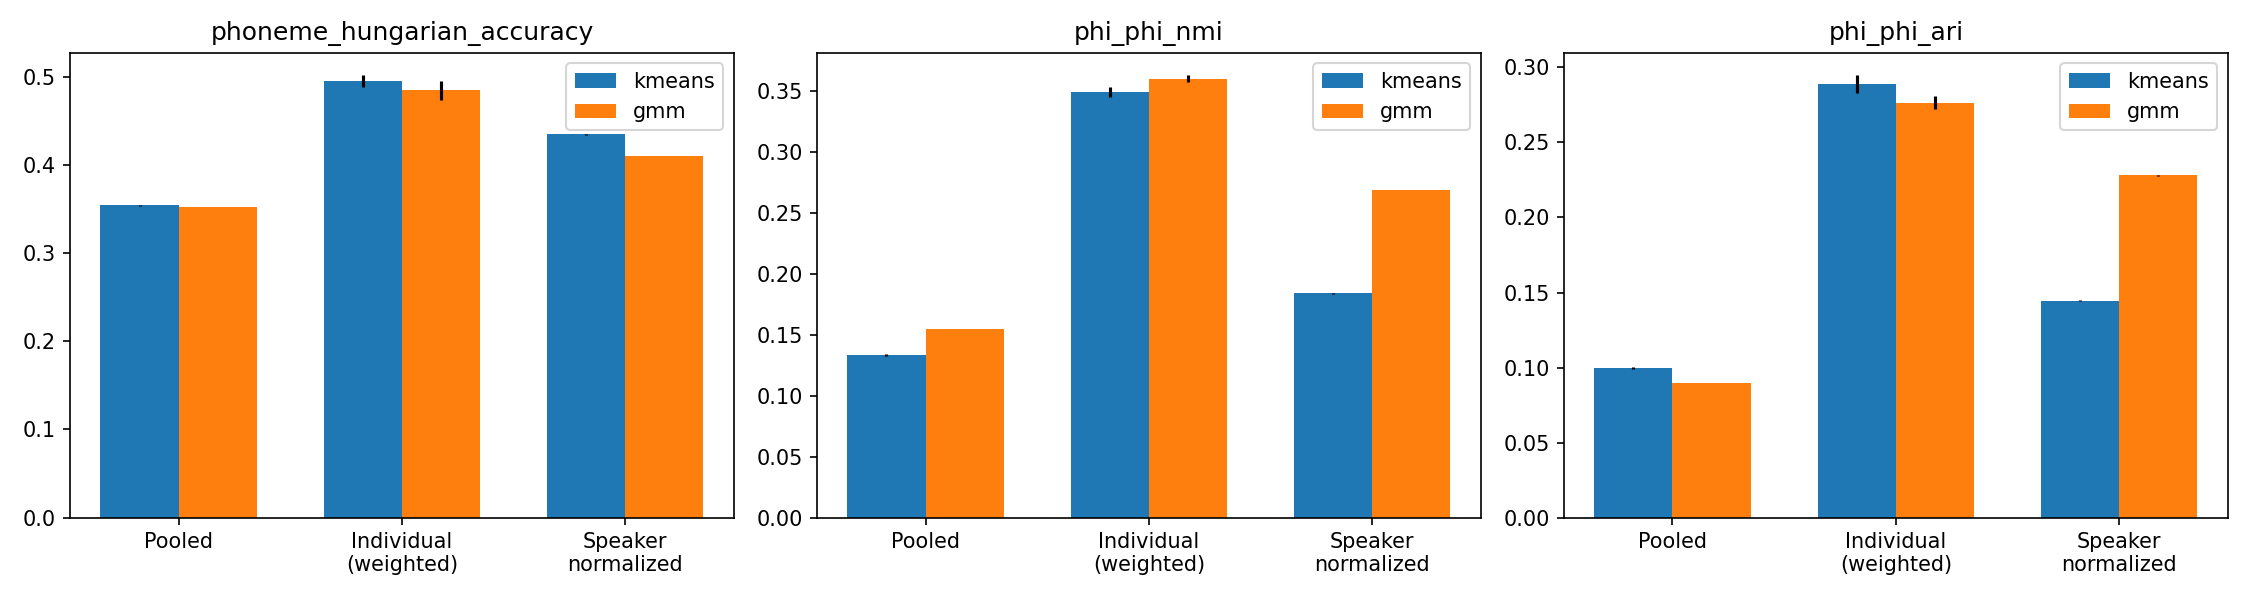

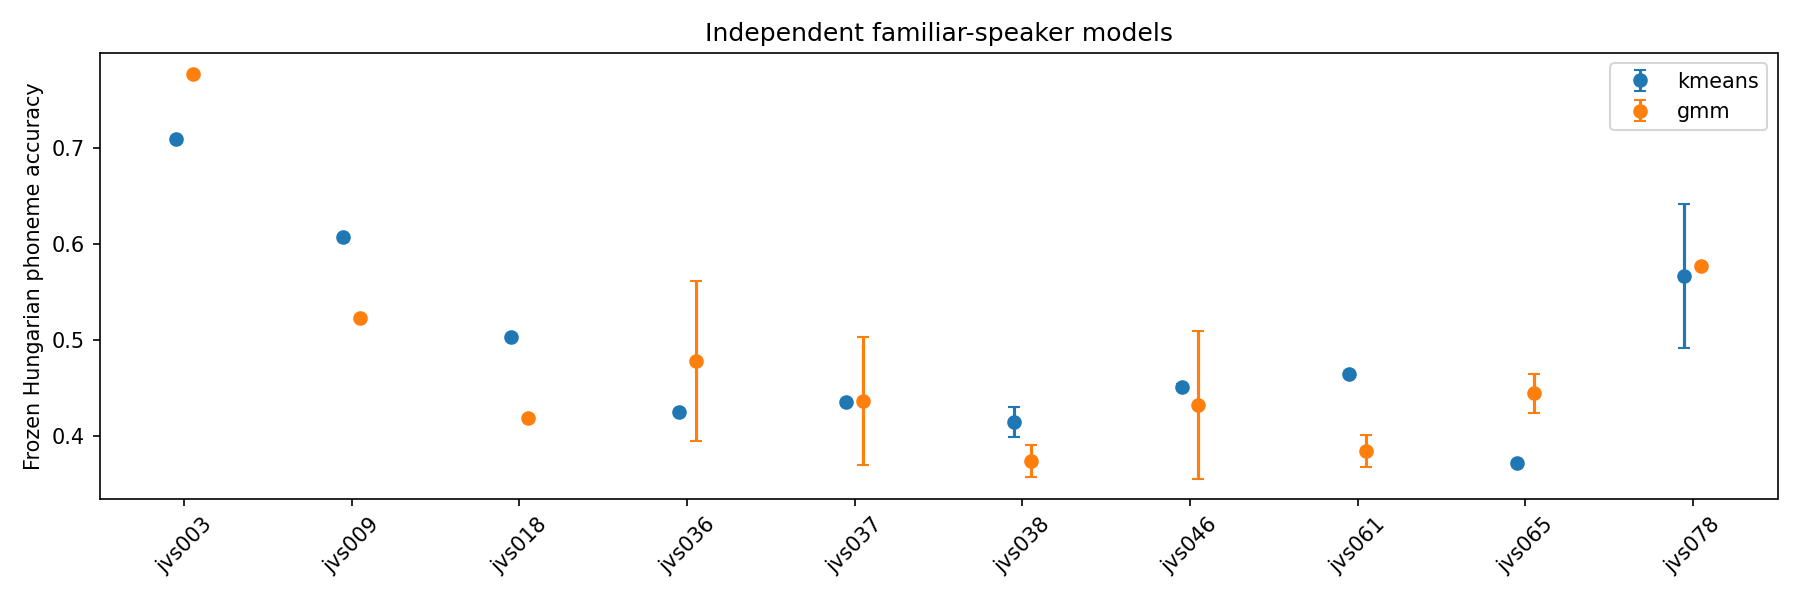

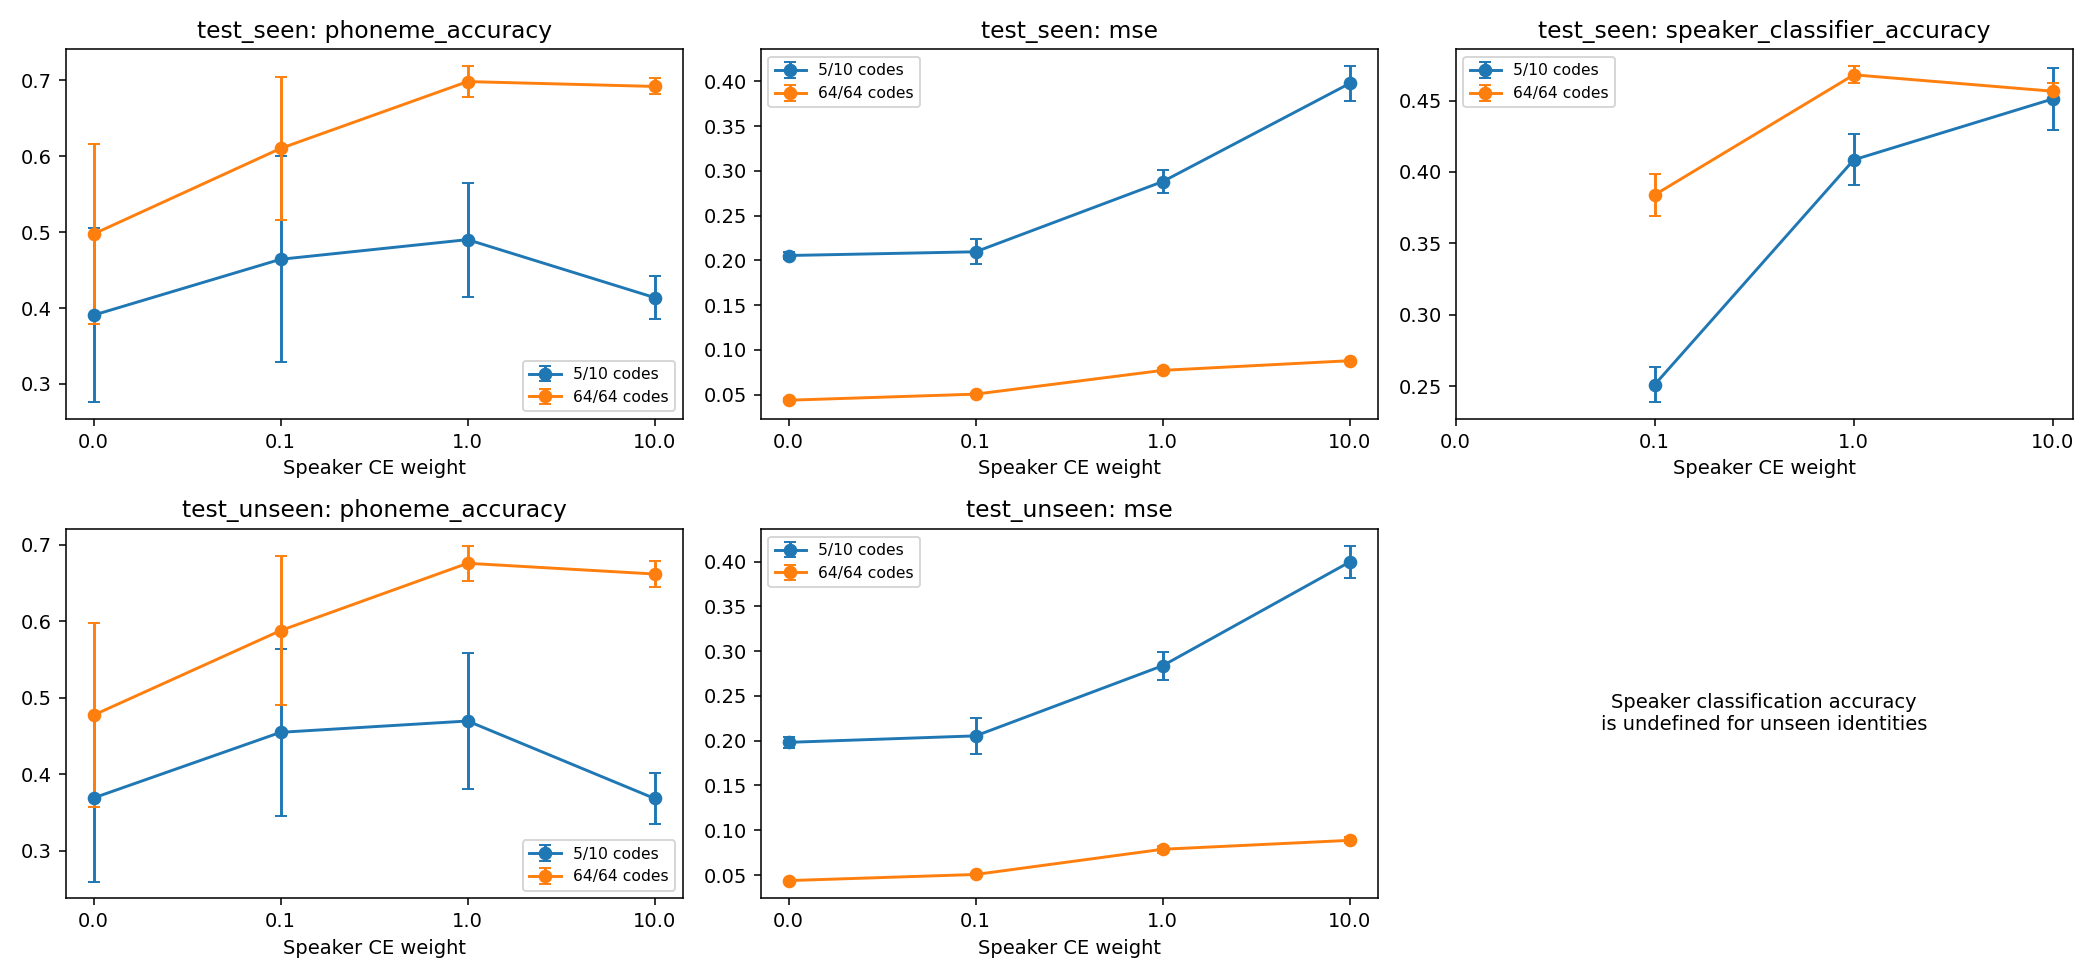

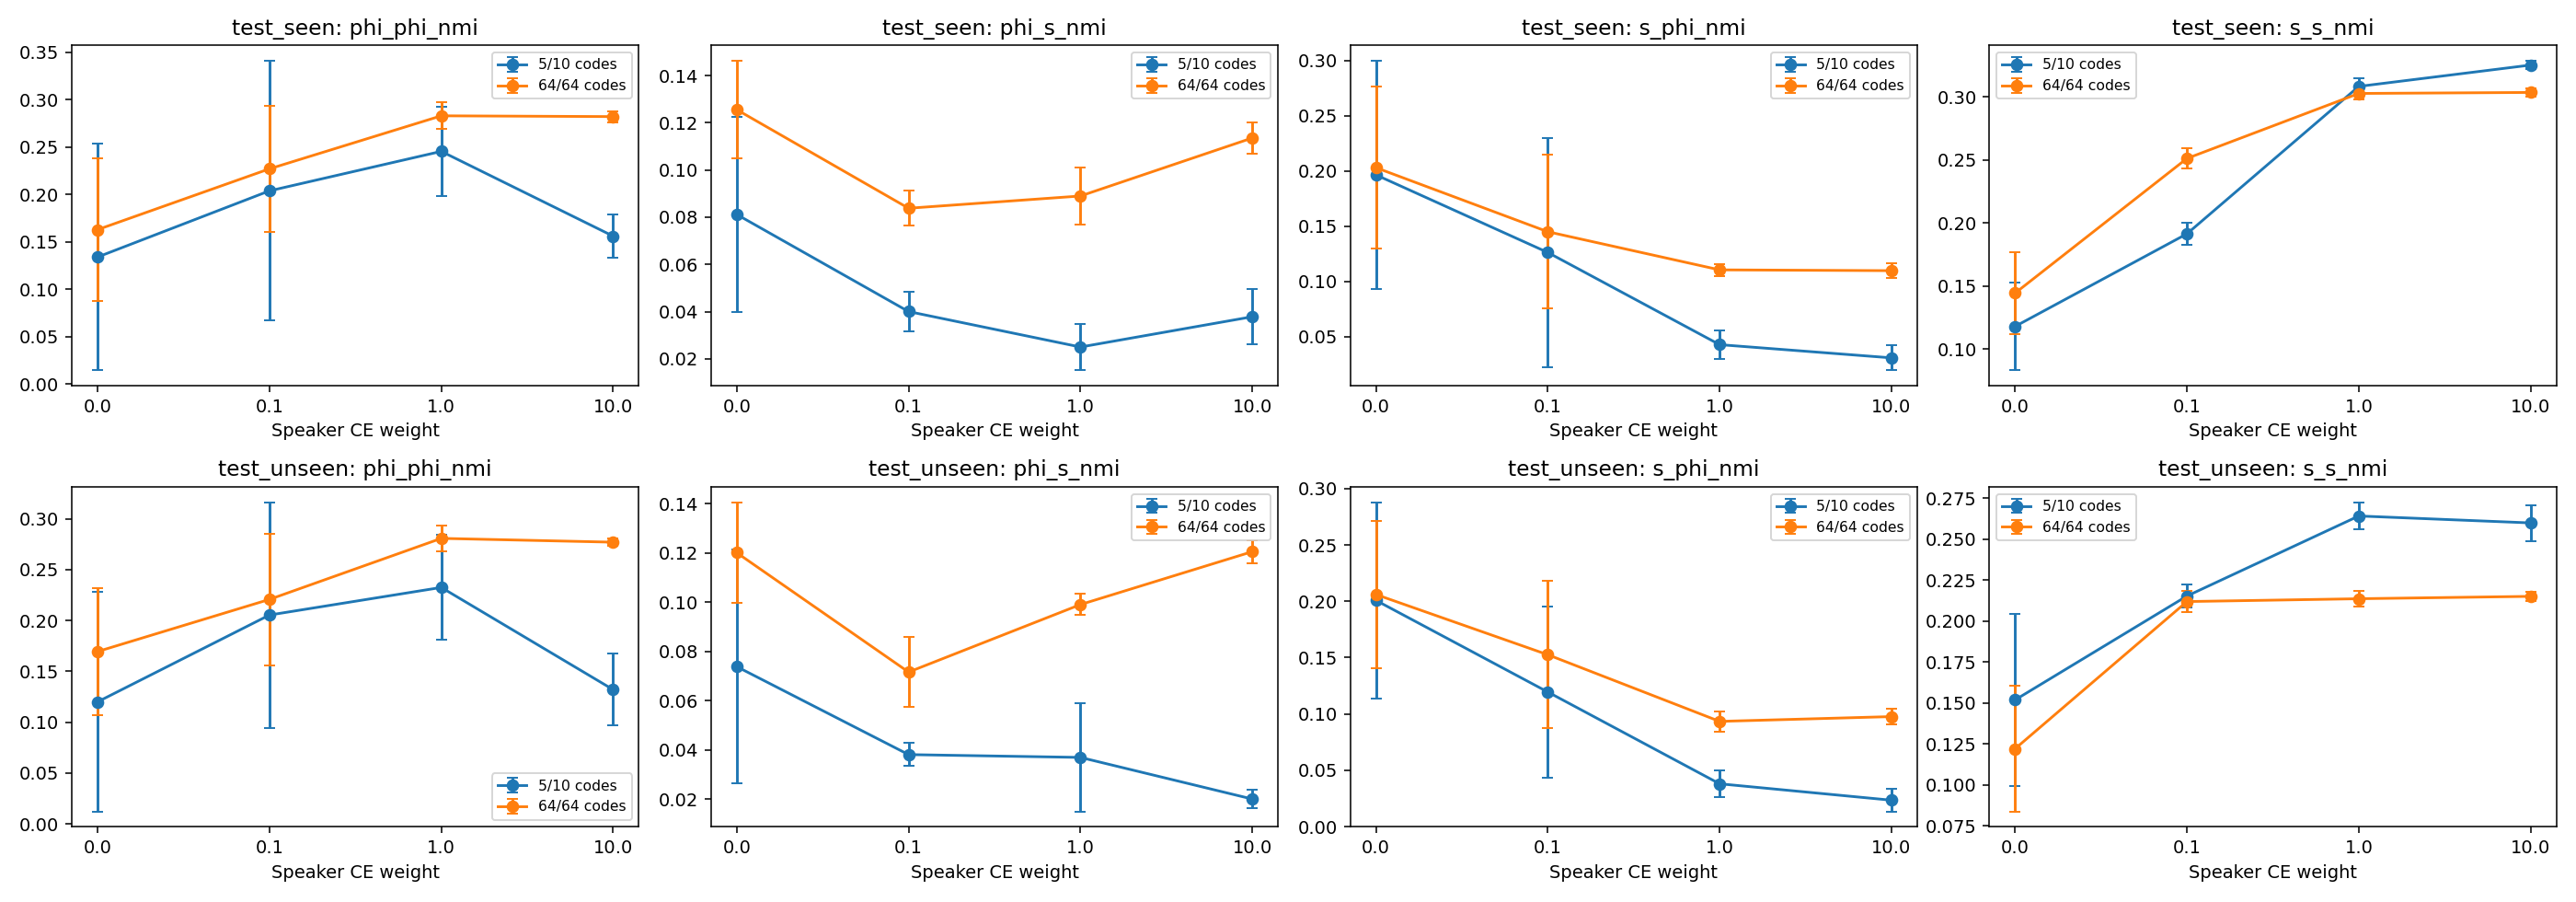

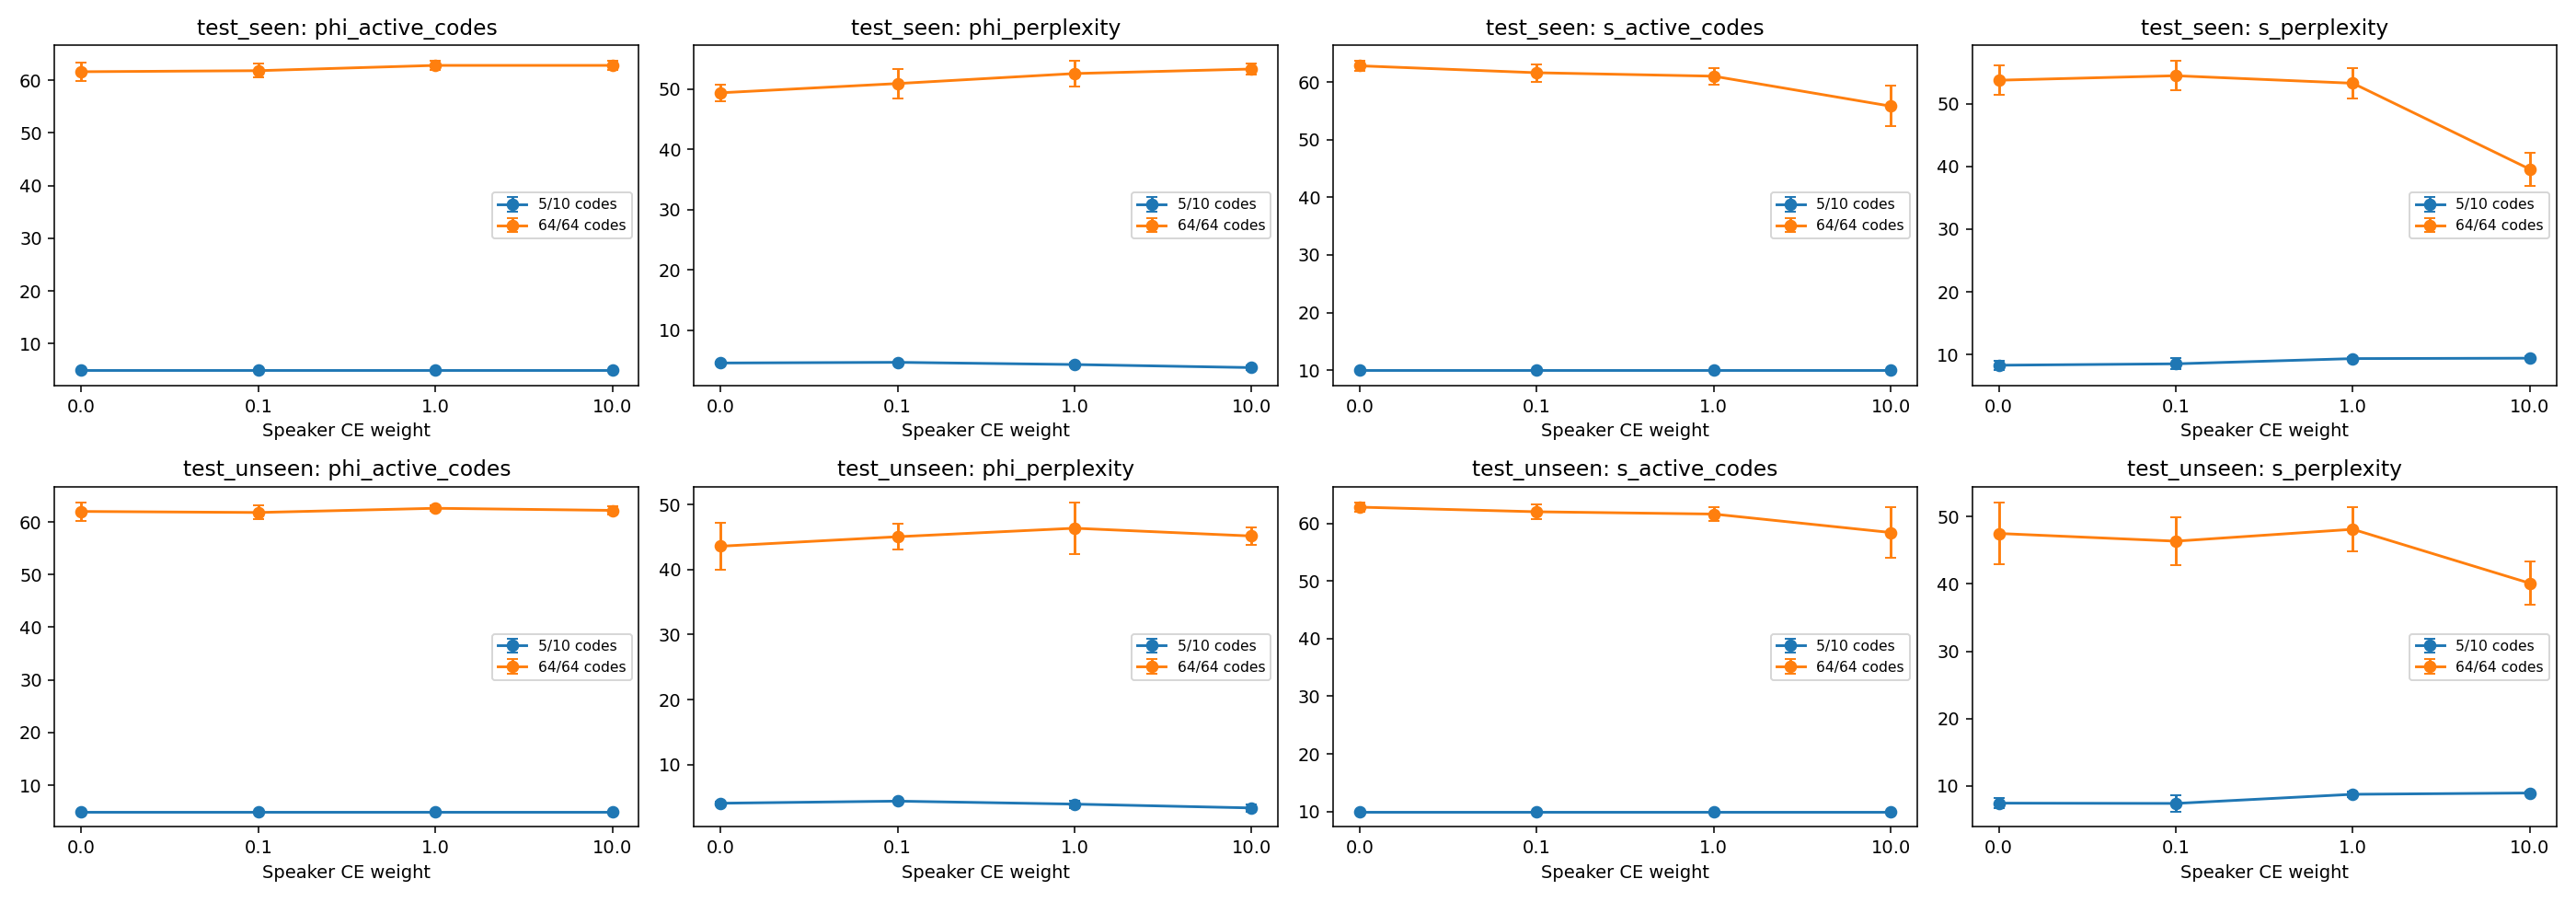

In [4]:
from src.sensitivity_report import make_sensitivity_report
report = make_sensitivity_report(run_dir)
display(Markdown('\n'.join(line for line in report.read_text(encoding='utf-8').splitlines() if not line.startswith('!['))))
for figure in ('raw_clusterability','individual_speakers','dose_response','factor_information','usage'):
    display(Image(filename=str(run_dir/'figures'/f'{figure}.png')))

In [5]:
import numpy as np
from threadpoolctl import threadpool_limits
from src.vq_data import prepare_vq_data
from src.vq_training import predict_vq
from src.sensitivity_training import load_sensitivity
from src.training import seed_everything
data = prepare_vq_data(config)
seed_everything(42,config.threads)
trial = run_dir/'vq'/'K64_64_lambda_1_seed_42'
model, info = load_sensitivity(trial,config)
with threadpool_limits(config.threads):
    out = predict_vq(model,data.x['test_unseen'])
saved = np.load(trial/'test_unseen_representations.npz')
for key in ('k_phi','k_s','reconstruction','speaker_logits'):
    np.testing.assert_array_equal(out[key],saved[key])
trained = pd.DataFrame(json.loads((run_dir/'trained.json').read_text()))
assert trained.groupby(['k_phi','k_s','seed']).initial_state_sha256.nunique().eq(1).all()
assert trained.groupby('seed').initial_neural_sha256.nunique().eq(1).all()
assert trained.groupby('seed').minibatch_order_sha256.nunique().eq(1).all()
assert vq.loc[vq.split.eq('test_unseen'),'speaker_classifier_accuracy'].isna().all()
print('Checkpoint reproduces unseen predictions exactly; matched initialization and minibatches verified.')
print('Report:',report)

Checkpoint reproduces unseen predictions exactly; matched initialization and minibatches verified.
Report: E:\SynologyDrive\Documents\research\variation_perceptual_magnet\codes\outputs\vq_sensitivity\20260929_011130_ec2936\REPORT.md


C:\Users\46021\.conda\envs\lffl\Lib\site-packages\torch\_utils.py:831: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()
